# Modeling Template

This is a template made for loading data from thousands of random Pokemon generation 9 battles from https://pokemonshowdown.com/ and using features from a csv to create models which predict the winner. 

# Outline
## Section 1: Modeling
### 1.1 Logistic Regression
    1.1.1 Baseline model
    1.1.2 Improvements
### 1.2 Decision Tree
### 1.3 Random Forest
### 1.4 
### 1.5
## Section 2: Model Comparisons
### 2.1 AUC score
### 2.2 Cross Validation Score
## Section 3: Best Model Analysis
### 3.1 ROC Curve
### 3.2 Confusion Matrix

In [43]:
# Import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier

In [45]:
# Load in training dataframe
path_to_train = "../data/data_cleaned.csv.zip"
full_df = pd.read_csv(path_to_train)
df = full_df[full_df["p1elo0"] > 0]
df['elo_diff'] = df['p1elo0'] - df['p2elo0']
train_df,test_df = train_test_split(df,test_size=0.2,shuffle=True,random_state=207)

print(train_df.columns.tolist())

# Load in testing dataframe
# path_to_test = "<replace with path to test data csv>"
# test_df = pd.read_csv(path_to_test)
# print(test_df.columns.tolist())

['format', 'id', 'p1_win', 'ratedQ', 'n_turns', 'start_time', 'end_time', 'duration', 'p1name', 'p1side', 'p1elo0', 'p1elo1', 'p2name', 'p2side', 'p2elo0', 'p2elo1', 'type_diversity_diff', 'num_boosting_abilities_diff', 'num_move_boosters_diff', 'total_stat_diff', 'p1_total_adv', 'p1_revealed_team_size', 'p2_revealed_team_size', 'M11_name', 'M11_speciesId', 'M11_used', 'M11_gender', 'M11_shinyQ', 'M11_level', 'M11_ability', 'M11_item', 'M11_teraType', 'M11_role', 'M11_mv1', 'M11_mv2', 'M11_mv3', 'M11_mv4', 'M11_type1', 'M11_type2', 'M11_hp', 'M11_atk', 'M11_def', 'M11_spa', 'M11_spd', 'M11_spe', 'M11_off', 'M12_name', 'M12_speciesId', 'M12_used', 'M12_gender', 'M12_shinyQ', 'M12_level', 'M12_ability', 'M12_item', 'M12_teraType', 'M12_role', 'M12_mv1', 'M12_mv2', 'M12_mv3', 'M12_mv4', 'M12_type1', 'M12_type2', 'M12_hp', 'M12_atk', 'M12_def', 'M12_spa', 'M12_spd', 'M12_spe', 'M12_off', 'M13_name', 'M13_speciesId', 'M13_used', 'M13_gender', 'M13_shinyQ', 'M13_level', 'M13_ability', 'M13_i

/var/folders/0j/z6dzxfws7yld9pqcrrz48ll4001p55/T/ipykernel_5874/145133825.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['elo_diff'] = df['p1elo0'] - df['p2elo0']


# Section 1: Modeling
## 1.1 Logistic Regression
### 1.1.1 Baseline Model

We begin with a simple model using only one feature to predict battle outcome. Following models will add features to see if this baseline model can be improved.

In [46]:
########## BASELINE MODEL ##########
base_feature = ["elo_diff"]
X_train_base = train_df[base_feature]
y_train = train_df["p1_win"]

X_test_base = test_df[base_feature]
y_test = test_df["p1_win"]

baseline = LogisticRegression(
    max_iter=1000,
    C=np.inf
)

baseline.fit(X_train_base, y_train)

base_pred = baseline.predict_proba(X_test_base)[:,1]

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


### 1.1.2 Improvements

In [47]:
########## IMPROVED MODEL ##########
features = [
    "elo_diff",
    "p1_total_adv",
    "total_stat_diff",
    "type_diversity_diff",
    "num_move_boosters_diff",
    "num_boosting_abilities_diff"
]
X_train = train_df[features]

X_test = test_df[features]

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train, y_train)

lr_pred = lr.predict_proba(X_test)[:,1]

## 1.2 Decision Tree

In [48]:
# Do a grid search for decision tree parameters
dt_param_grid = {
    "max_depth": [3, 5, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    param_grid=dt_param_grid,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best parameters:")
print(dt_grid.best_params_)

Best parameters:
{'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [49]:
dt = DecisionTreeClassifier(
    random_state=0,
    max_depth = 3,
    min_samples_leaf= 10,
    min_samples_split= 2
)

dt.fit(X_train, y_train)

dt_pred = dt.predict_proba(X_test)[:,1]

## 1.3 Random Forest

In [50]:
# Do a grid search for random forest parameters
rf_param_grid = {
    "max_depth": [4, 6, 8, 10],
    "min_samples_leaf": [5, 10, 20],
    "n_estimators": [200, 500, 800]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

Best parameters:
{'max_depth': 4, 'min_samples_leaf': 10, 'n_estimators': 200}


In [51]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    min_samples_leaf=10,
    random_state=0,
)

rf.fit(X_train, y_train)

rf_pred = rf.predict_proba(X_test)[:,1]

## 1.4 Histogram-based Gradient Boosting Classification Tree

In [52]:
# Do a grid search for HistGradientBoosting parameters
hgb_param_grid = {
    "max_depth": [4, 6, 8, 10],
    "min_samples_leaf": [5, 10, 20],
    "max_iter": [100, 200, 500] 
}

grid = GridSearchCV(
    HistGradientBoostingClassifier(random_state=0),
    param_grid=hgb_param_grid,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

Best parameters:
{'max_depth': 4, 'max_iter': 100, 'min_samples_leaf': 10}


In [53]:
hgb = HistGradientBoostingClassifier(
    max_iter=100,
    max_depth=4,
    min_samples_leaf=10,
    random_state=0,
)

hgb.fit(X_train, y_train)

hgb_pred = hgb.predict_proba(X_test)[:, 1]

## 1.5 XGBoost

In [54]:
# Do a grid search for XGBoost parameters
xgb_param_grid = {
    "max_depth": [4, 6, 8, 10],
    "min_child_weight": [5, 10, 20], 
    "n_estimators": [200, 500, 800] 
}

grid = GridSearchCV(
    XGBClassifier(random_state=0),
    param_grid=xgb_param_grid,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

Best parameters:
{'max_depth': 4, 'min_child_weight': 20, 'n_estimators': 200}


In [55]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    min_child_weight=20,
    random_state=0,
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict_proba(X_test)[:, 1]

# Section 2: Model Comparisons
## 2.1 AUC score

In [56]:
print(f"AUC Scores")
print(f"Baseline Model: {roc_auc_score(y_test, base_pred)}")
print(f"Logistic Regression: {roc_auc_score(y_test, lr_pred)}")
print(f"Decision Tree: {roc_auc_score(y_test, dt_pred)}")
print(f"Random Forest: {roc_auc_score(y_test, rf_pred)}")
print(f"HistGradientBoosting: {roc_auc_score(y_test, hgb_pred)}")
print(f"XGBoost: {roc_auc_score(y_test, xgb_pred)}")

AUC Scores
Baseline Model: 0.5249739165539442
Logistic Regression: 0.5422060303878701
Decision Tree: 0.5265720191470843
Random Forest: 0.530586444996697
HistGradientBoosting: 0.5104861351410865
XGBoost: 0.49662225927207526


## 2.2 Cross Validation Score

In [57]:
lr_cvscore = cross_val_score(lr, X_train, y_train, cv=5, scoring="roc_auc")
dt_cvscore = cross_val_score(dt, X_train, y_train, cv=5, scoring="roc_auc")
rf_cvscore = cross_val_score(rf, X_train, y_train, cv=5, scoring="roc_auc")
hgb_cvscore = cross_val_score(hgb, X_train, y_train, cv=5, scoring="roc_auc")
xgb_cvscore = cross_val_score(xgb, X_train, y_train, cv=5, scoring="roc_auc")

print("Cross-Validation Scores") 
print(f"Logistic Regression: {lr_cvscore.mean():.3f} +/- {lr_cvscore.std():.3f}")
print(f"Decision Tree: {dt_cvscore.mean():.3f} +/- {dt_cvscore.std():.3f}")
print(f"Random Forest: {rf_cvscore.mean():.3f} +/- {rf_cvscore.std():.3f}")
print(f"HistGradientBoosting: {hgb_cvscore.mean():.3f} +/- {hgb_cvscore.std():.3f}")
print(f"XGBoost: {xgb_cvscore.mean():.3f} +/- {xgb_cvscore.std():.3f}")

Cross-Validation Scores
Logistic Regression: 0.540 +/- 0.014
Decision Tree: 0.525 +/- 0.005
Random Forest: 0.533 +/- 0.007
HistGradientBoosting: 0.518 +/- 0.007
XGBoost: 0.514 +/- 0.010


# Section 3: Best Model Analysis
## 3.1 ROC Curve

#### Choose best model and uncomment it below
 - Logistic regression model = lr
 - Decision tree model = dt
 - Random forest model = rf

In [58]:
# Choose best model
best_model = lr
#best_model = dt
#best_model = rf

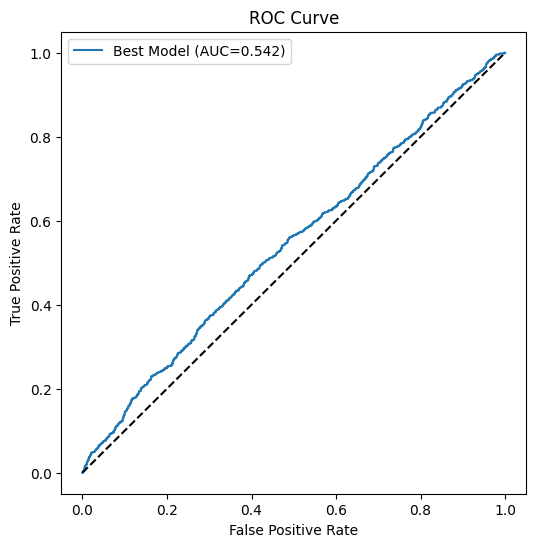

In [59]:
# Random forest
prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"Best Model (AUC={roc_auc_score(y_test, prob):.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## 3.2 Confusion Matrix

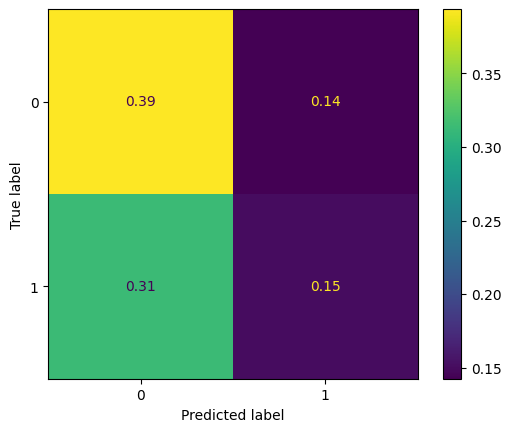

In [60]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    normalize='all'
)

Note the lack of symmetry.  The model predicts that player 1 will lose 70% of the time when in reality, they lose 53% of the time.  This is likely because of the seeming inherent disadvantage imposed on the p1 slot.  p1 tends to have the player with lower rating (average elo_diff is -15).

In [61]:
print("elo diff mean", X_train["elo_diff"].mean())
print("adv mean", X_train["p1_total_adv"].mean())
print("type div diff mean", X_train["type_diversity_diff"].mean())
print("num_move_boosters_diff mean", X_train["num_move_boosters_diff"].mean())
print("num_boosting_abilities_diff mean",X_train["num_boosting_abilities_diff"].mean())

elo diff mean -13.487277867528272
adv mean 0.08857888049462215
type div diff mean -0.00020193861066235866
num_move_boosters_diff mean -0.0013126009693053312
num_boosting_abilities_diff mean -0.009390145395799677


<Axes: xlabel='elo_diff', ylabel='Count'>

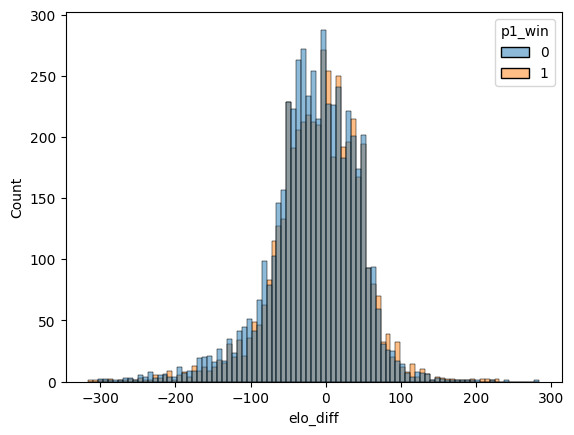

In [66]:
import seaborn as sns

sns.histplot(data=train_df, x='elo_diff', hue='p1_win')

In [67]:
train_df["predictions"] = lr.predict(X_train[features])

<Axes: xlabel='elo_diff', ylabel='Count'>

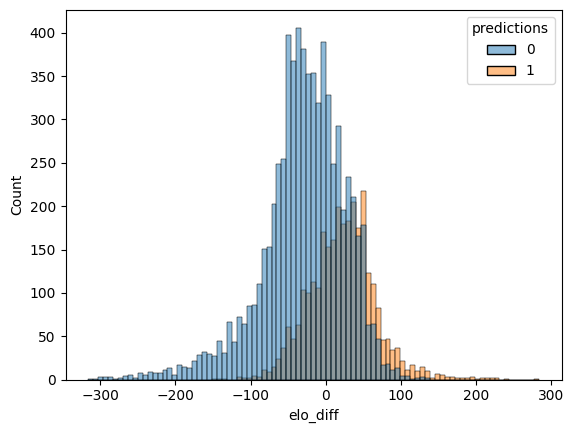

In [69]:
sns.histplot(data = train_df,x='elo_diff',hue='predictions')

<Axes: xlabel='p1_total_adv', ylabel='Count'>

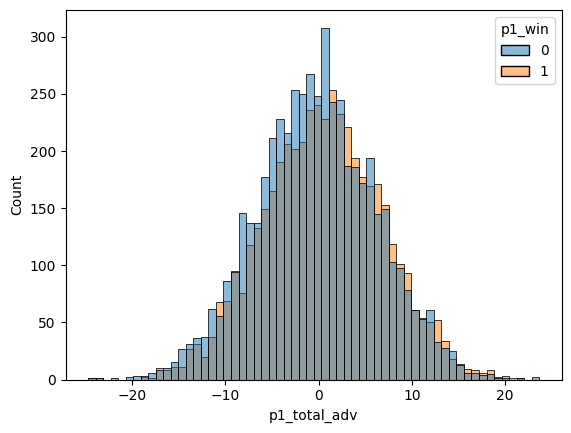

In [70]:
sns.histplot(data=train_df,x='p1_total_adv',hue='p1_win')

<Axes: xlabel='p1_total_adv', ylabel='Count'>

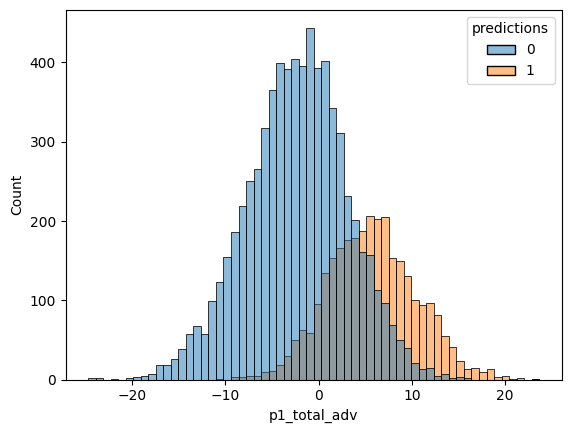

In [71]:
sns.histplot(data=train_df,x='p1_total_adv',hue='predictions')